In [ ]:
import pandas as pd
import numpy as np
import tensorflow as tf
from tensorflow.keras import layers, models
from tensorflow.keras.callbacks import EarlyStopping
from scipy.interpolate import griddata
import warnings
warnings.filterwarnings('ignore')

print("Step 1: Loading Datasets...")
df_floods = pd.read_csv("India_Flood_Inventory_v3.csv")
df_rain = pd.read_csv("51acd4ce-fb56-43f5-9a0b-ea621a1b9683.csv")

df_rain['Date'] = pd.to_datetime(df_rain['Data Acquisition Time']).dt.date
df_floods['Start Date'] = pd.to_datetime(df_floods['Start Date'], errors='coerce').dt.date

print("Step 2: Spatial Gridding...")
min_lat, max_lat = df_rain['Latitude'].min(), df_rain['Latitude'].max()
min_lon, max_lon = df_rain['Longitude'].min(), df_rain['Longitude'].max()
grid_size = 32
grid_x, grid_y = np.mgrid[min_lon:max_lon:complex(grid_size), min_lat:max_lat:complex(grid_size)]

unique_days = sorted(df_rain['Date'].dropna().unique())
X_grids, y_labels = [], []
flood_start_dates = set(df_floods['Start Date'].dropna())

for day in unique_days:
    daily_rain = df_rain[df_rain['Date'] == day]
    daily_rain = daily_rain.groupby(['Longitude', 'Latitude'], as_index=False)['Manual Daily Rainfall (mm)'].mean()

    points = daily_rain[['Longitude', 'Latitude']].values
    values = daily_rain['Manual Daily Rainfall (mm)'].values

    if len(points) >= 4:
        try:
            grid_z = griddata(points, values, (grid_x, grid_y), method='linear', fill_value=0.0)
        except Exception:
            grid_z = griddata(points, values, (grid_x, grid_y), method='nearest')
            grid_z = np.nan_to_num(grid_z, nan=0.0)
    else:
        grid_z = np.zeros((grid_size, grid_size))

    X_grids.append(grid_z)

    target_grid = np.zeros((grid_size, grid_size))
    if day in flood_start_dates:
        # Lower threshold to capture more flood data points
        threshold = np.percentile(grid_z, 85) if np.max(grid_z) > 0 else 1
        target_grid[grid_z >= threshold] = 1.0

    y_labels.append(target_grid)

X_data = np.array(X_grids)[..., np.newaxis]
y_data = np.array(y_labels)[..., np.newaxis]
X_data = X_data / (np.max(X_data) + 1e-7)

print("Step 3: Creating Sequences...")
time_steps = 3
X_seq, y_seq = [], []
for i in range(len(X_data) - time_steps):
    X_seq.append(X_data[i : i + time_steps])
    y_seq.append(y_data[i + time_steps])

X_seq = np.array(X_seq)
y_seq = np.array(y_seq)

# --- THE FIX: CUSTOM DICE LOSS FUNCTION ---
# This forces the model to ignore dry land and focus ONLY on overlapping the flood zones
def dice_loss(y_true, y_pred):
    y_true = tf.cast(y_true, tf.float32)
    y_pred = tf.cast(y_pred, tf.float32)

    # Calculate the overlap
    numerator = 2 * tf.reduce_sum(y_true * y_pred)
    # Calculate the total area
    denominator = tf.reduce_sum(y_true + y_pred)

    # Subtract from 1 because we want to MINIMIZE the loss (1 means perfect overlap, 0 means no overlap)
    return 1 - (numerator + 1) / (denominator + 1)

print("Step 4: Building & Training Working Model...")
model = models.Sequential([
    layers.Input(shape=(time_steps, grid_size, grid_size, 1)),
    layers.ConvLSTM2D(filters=32, kernel_size=(3, 3), padding='same', return_sequences=False),
    layers.BatchNormalization(),
    layers.Dropout(0.2),
    layers.Conv2D(filters=1, kernel_size=(3, 3), activation='sigmoid', padding='same')
])

# Compile using our new Computer Vision loss function
optimizer = tf.keras.optimizers.Adam(learning_rate=0.001)
model.compile(optimizer=optimizer, loss=dice_loss, metrics=['accuracy'])

early_stopping = EarlyStopping(monitor='val_loss', patience=3, restore_best_weights=True)

history = model.fit(
    X_seq, y_seq,
    batch_size=8,
    epochs=15,
    validation_split=0.2,
    callbacks=[early_stopping],
    verbose=1
)

print("Working Model built and trained successfully!")

Step 1: Loading Datasets...
Step 2: Spatial Gridding...
Step 3: Creating Sequences...
Step 4: Building & Training Working Model...
Epoch 1/15
130/130 ━━━━━━━━━━━━━━━━━━━━ 38s 269ms/step - accuracy: 0.6628 - loss: 0.9424 - val_accuracy: 0.1490 - val_loss: 0.9998
Epoch 2/15
130/130 ━━━━━━━━━━━━━━━━━━━━ 43s 328ms/step - accuracy: 0.7117 - loss: 0.9345 - val_accuracy: 0.9241 - val_loss: 0.9993
Epoch 3/15
130/130 ━━━━━━━━━━━━━━━━━━━━ 74s 272ms/step - accuracy: 0.7526 - loss: 0.9253 - val_accuracy: 0.8493 - val_loss: 0.9980
Epoch 4/15
130/130 ━━━━━━━━━━━━━━━━━━━━ 41s 269ms/step - accuracy: 0.7991 - loss: 0.9282 - val_accuracy: 0.9940 - val_loss: 0.7802
Epoch 5/15
130/130 ━━━━━━━━━━━━━━━━━━━━ 33s 255ms/step - accuracy: 0.8789 - loss: 0.9244 - val_accuracy: 0.9827 - val_loss: 0.9094
Epoch 6/15
130/130 ━━━━━━━━━━━━━━━━━━━━ 35s 271ms/step - accuracy: 0.9115 - loss: 0.9146 - val_accuracy: 0.9780 - val_loss: 0.9132
Epoch 7/15
130/130 ━━━━━━━━━━━━━━━━━━━━ 35s 266ms/step - accuracy: 0.8955 - loss: 0

Running full dataset inference...
--- 4. Pixel-Wise Confusion Matrix ---


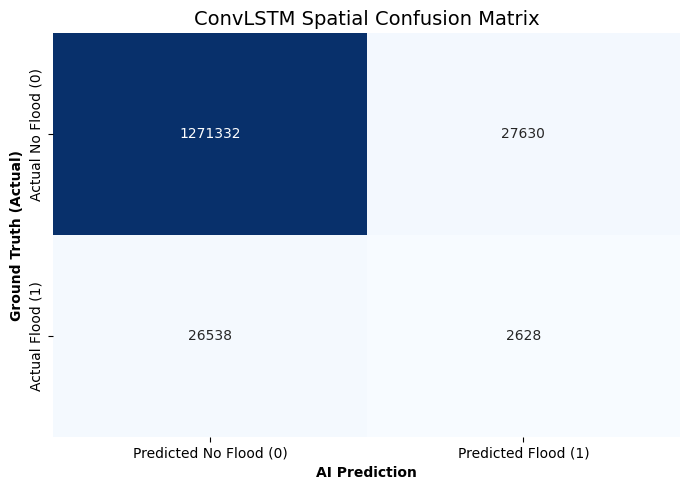


--- 5. Classification Report ---
              precision    recall  f1-score   support

No Flood (0)       0.98      0.98      0.98   1298962
   Flood (1)       0.09      0.09      0.09     29166

    accuracy                           0.96   1328128
   macro avg       0.53      0.53      0.53   1328128
weighted avg       0.96      0.96      0.96   1328128



In [ ]:
from sklearn.metrics import confusion_matrix, classification_report
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np

print("Running full dataset inference...")
# Generate predictions for the entire sequence
y_pred_probs = model.predict(X_seq, verbose=0)

# Convert probabilities to binary predictions (Flood vs No Flood)
# Using a threshold of 0.5 (50% probability)
y_pred_binary = (y_pred_probs > 0.5).astype(int)
y_true_binary = y_seq.astype(int)

# Flatten the 3D spatial grids into 1D arrays for standard metric calculations
y_pred_flat = y_pred_binary.flatten()
y_true_flat = y_true_binary.flatten()

# Calculate the Confusion Matrix
cm = confusion_matrix(y_true_flat, y_pred_flat)

print("--- 4. Pixel-Wise Confusion Matrix ---")
plt.figure(figsize=(7, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', cbar=False,
            xticklabels=['Predicted No Flood (0)', 'Predicted Flood (1)'],
            yticklabels=['Actual No Flood (0)', 'Actual Flood (1)'])
plt.title('ConvLSTM Spatial Confusion Matrix', fontsize=14)
plt.ylabel('Ground Truth (Actual)', fontweight='bold')
plt.xlabel('AI Prediction', fontweight='bold')
plt.tight_layout()
plt.show()

print("\n--- 5. Classification Report ---")
# Zero_division=0 prevents warnings if the model completely missed the 'Flood' class
report = classification_report(y_true_flat, y_pred_flat,
                               target_names=['No Flood (0)', 'Flood (1)'],
                               zero_division=0)
print(report)

--- 1. Raw Dataset Insights ---


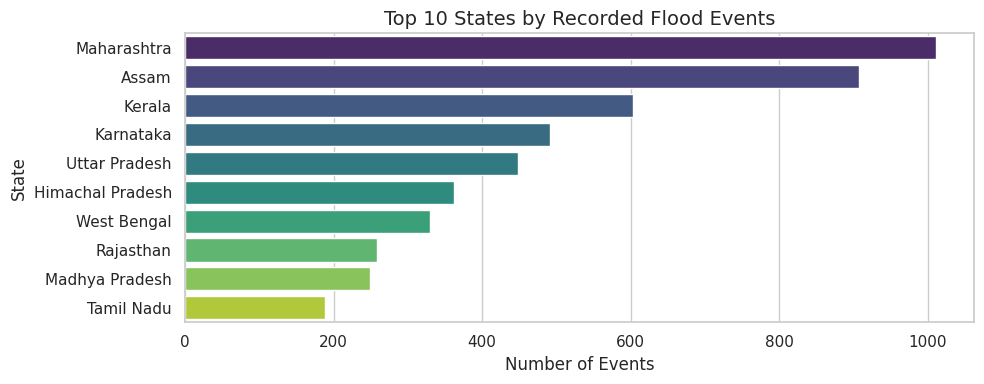


--- 2. Model Training Diagnostics ---


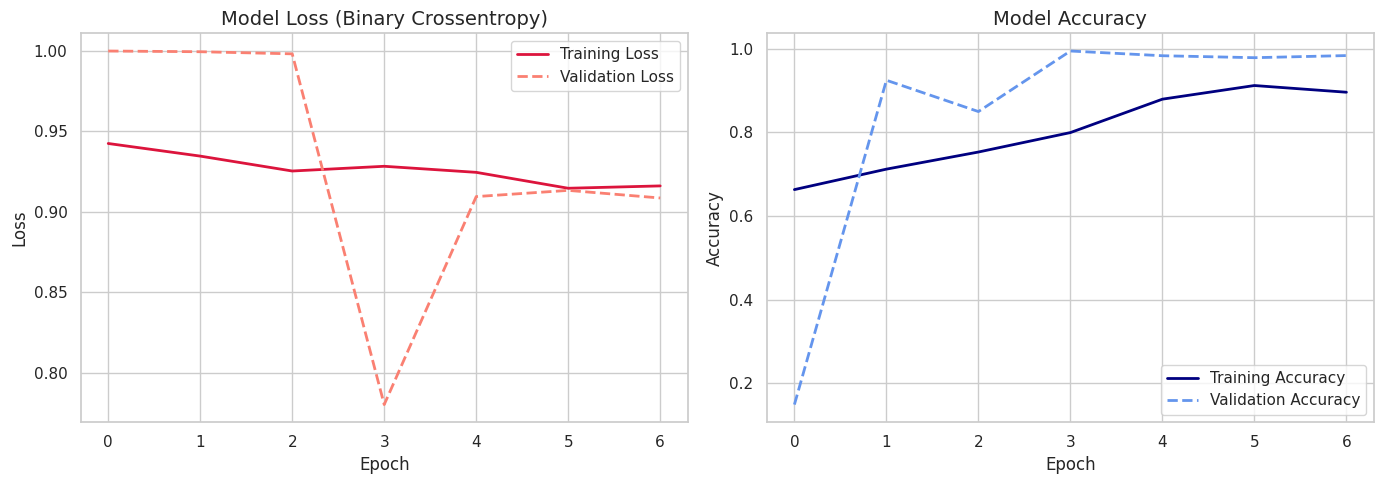


--- 3. Spatio-Temporal Prediction vs. Reality ---


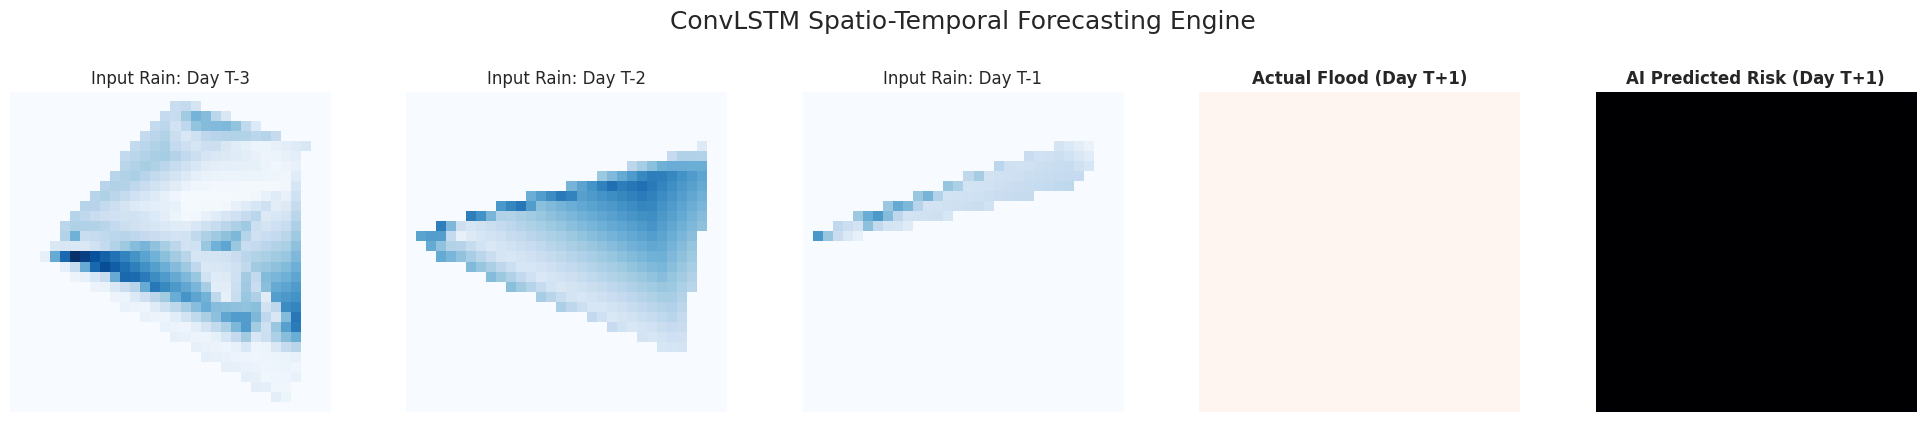

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
import random
import numpy as np

sns.set_theme(style="whitegrid")

print("--- 1. Raw Dataset Insights ---")
# Show the top 10 states most affected by floods in the inventory
plt.figure(figsize=(10, 4))
top_states = df_floods['State'].value_counts().head(10)
sns.barplot(x=top_states.values, y=top_states.index, palette='viridis')
plt.title('Top 10 States by Recorded Flood Events', fontsize=14)
plt.xlabel('Number of Events')
plt.ylabel('State')
plt.tight_layout()
plt.show()


print("\n--- 2. Model Training Diagnostics ---")
# Plotting training loss and accuracy
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Loss Curve
axes[0].plot(history.history['loss'], label='Training Loss', color='crimson', linewidth=2)
axes[0].plot(history.history['val_loss'], label='Validation Loss', color='salmon', linewidth=2, linestyle='--')
axes[0].set_title('Model Loss (Binary Crossentropy)', fontsize=14)
axes[0].set_ylabel('Loss')
axes[0].set_xlabel('Epoch')
axes[0].legend()

# Accuracy Curve
axes[1].plot(history.history['accuracy'], label='Training Accuracy', color='navy', linewidth=2)
axes[1].plot(history.history['val_accuracy'], label='Validation Accuracy', color='cornflowerblue', linewidth=2, linestyle='--')
axes[1].set_title('Model Accuracy', fontsize=14)
axes[1].set_ylabel('Accuracy')
axes[1].set_xlabel('Epoch')
axes[1].legend()

plt.tight_layout()
plt.show()


print("\n--- 3. Spatio-Temporal Prediction vs. Reality ---")
# Pick a random sequence from our test/train data to visualize
sample_idx = random.randint(0, len(X_seq) - 1)
sample_input = X_seq[sample_idx:sample_idx+1] # Shape: (1, 3, 32, 32, 1)
sample_target = y_seq[sample_idx]             # Shape: (32, 32, 1)

# Generate the model's prediction
prediction = model.predict(sample_input, verbose=0)[0]   # Shape: (32, 32, 1)

# Set up a 1x5 grid of images
fig, axes = plt.subplots(1, 5, figsize=(20, 4))

# Plot the 3 sequential days of input rainfall
for t in range(time_steps):
    ax = axes[t]
    # Blues colormap for rainfall
    im = ax.imshow(sample_input[0, t, :, :, 0], cmap='Blues', vmin=0, vmax=np.max(sample_input))
    ax.set_title(f'Input Rain: Day T-{time_steps-t}', fontsize=12)
    ax.axis('off')

# Plot the Actual Ground Truth Flood Label
axes[3].imshow(sample_target[:, :, 0], cmap='Reds', vmin=0, vmax=1)
axes[3].set_title('Actual Flood (Day T+1)', fontsize=12, fontweight='bold')
axes[3].axis('off')

# Plot the Model's Prediction
# Using 'magma' colormap to represent a "heat/risk" map
axes[4].imshow(prediction[:, :, 0], cmap='magma', vmin=0, vmax=1)
axes[4].set_title('AI Predicted Risk (Day T+1)', fontsize=12, fontweight='bold')
axes[4].axis('off')

plt.suptitle('ConvLSTM Spatio-Temporal Forecasting Engine', fontsize=18, y=1.05)
plt.tight_layout()
plt.show()